# Support Vector Machine (SVM)

## The Idea
Find the **best line** that separates two classes with **maximum margin**.

## Key Terms
- **Hyperplane**: The dividing line
- **Margin**: Distance between line and nearest points
- **Support Vectors**: Points closest to the line (they "support" it)
- **Kernel Trick**: Transform data to higher dimensions to separate it

In [1]:
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Create simple 2D data
X, y = make_classification(n_samples=100, n_features=2, n_redundant=0, 
                           n_informative=2, n_clusters_per_class=1, random_state=42)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train SVM
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)

# Predict
pred = svm.predict(X_test)
print(f"SVM Accuracy: {accuracy_score(y_test, pred):.4f}")

SVM Accuracy: 1.0000


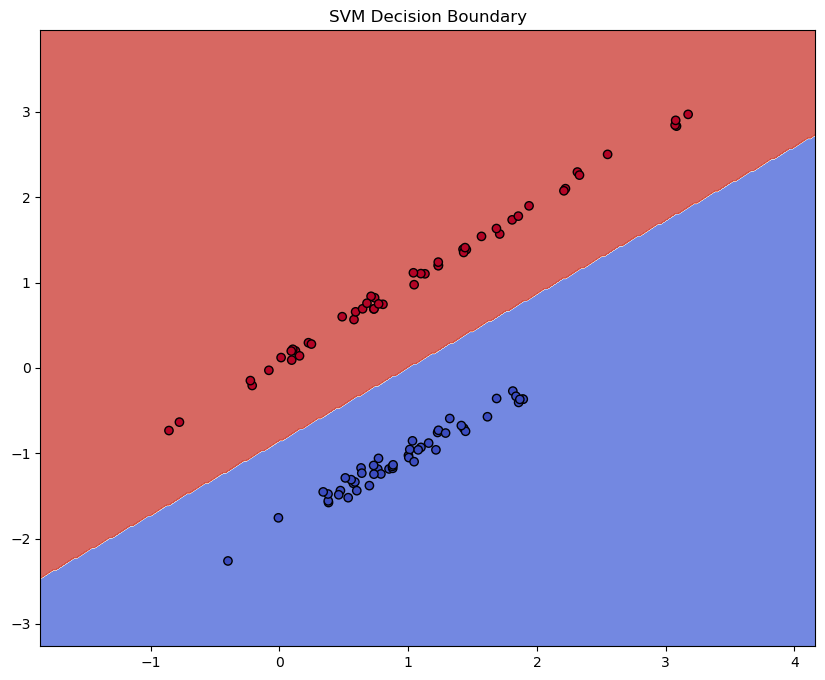

In [2]:
# Visualize SVM decision boundary
def plot_svm_boundary(model, X, y):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.title('SVM Decision Boundary')
    plt.show()

plot_svm_boundary(svm, X, y)

In [3]:
# Try different kernels
kernels = ['linear', 'rbf', 'poly']

for kernel in kernels:
    model = SVC(kernel=kernel)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"Kernel '{kernel}': Accuracy = {acc:.4f}")

Kernel 'linear': Accuracy = 1.0000
Kernel 'rbf': Accuracy = 1.0000
Kernel 'poly': Accuracy = 1.0000
